In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# The charge on an amino acid, and how it moves with temperature (Illustration 13.6-2, Figures 13.6-5, 13.6-6 and 13.6-11)

Glycine is the simplest amino acid and the only one without a chiral center. It also
carries both an acid and a base on the same three carbons, which means it is never
uncharged in the way a solvent molecule is uncharged -- it is either a cation, an anion,
or a **zwitterion** with a positive end and a negative end that cancel.

Section 13.6 describes it with two successive ionizations,

$$\underset{(A)}{\mathrm{^+H_3NCH_2COOH}}
\;\overset{K_1}{\rightleftharpoons}\;
\underset{(B)}{\mathrm{^+H_3NCH_2COO^-}}+\mathrm{H^+}
\;\overset{K_2}{\rightleftharpoons}\;
\underset{(C)}{\mathrm{H_2NCH_2COO^-}}+\mathrm{H^+}$$

with p$K_1=2.34$ and p$K_2=9.6$. Those are more than seven units apart, and Sec. 13.6
uses that: it solves the two reactions **separately**, on the argument that the first has
finished before the second begins.

Figure 13.6-4 in the printed book labels **both** of these reactions $K_1$. The second
is $K_2$.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import AminoAcid, PolyproticAcid
from thermo.charts import use_book_style

use_book_style()

glycine = AminoAcid(2.34, 9.6, "glycine")
pH = np.linspace(0.0, 15.0, 1501)          # the axes of Figs. 13.6-5 and 13.6-6


## The three fractions

Taking the two reactions separately, Eq. 13.6-5d gives the cationic fraction and
Eq. 13.6-6b the anionic one,

$$\frac{M_A}{M_{B,o}}=\frac{10^{\,\mathrm{p}K_1-\mathrm{pH}}}{1+10^{\,\mathrm{p}K_1-\mathrm{pH}}}
\qquad
\frac{M_C}{M_{B,o}}=\frac{1}{1+10^{\,\mathrm{p}K_2-\mathrm{pH}}}$$

and the neutral zwitterion is what is left over. Both signs are printed correctly.


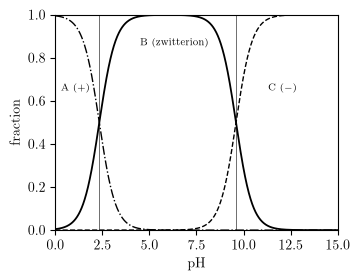

the illustration's own reading of Fig. 13.6-5:
  at pH 5   f_A = 0.00218   'the positively charged (A) species have essentially disappeared'
  at pH 8   f_C = 0.02450   'the (C) species begin to appear only above about pH = 8'

  and the zwitterion holds above 0.99 from pH 4.34 to 7.60


In [3]:
f = glycine.fractions(pH)

fig_5, ax = plt.subplots(figsize=(3.7, 2.9))
ax.plot(pH, f[0], "-.", color="k", lw=1.0, label=r"A  ($+$)")
ax.plot(pH, f[1], "-",  color="k", lw=1.3, label=r"B  (zwitterion)")
ax.plot(pH, f[2], "--", color="k", lw=1.0, label=r"C  ($-$)")
for p in (glycine.pK1, glycine.pK2):
    ax.axvline(p, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("fraction")
ax.set_xlim(0, 15); ax.set_ylim(0, 1); ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
# NAME THE CURVES IN PLACE -- no legend. Anywhere on the right-hand side a legend puts
# its SAMPLE LINES across the A/B/C crossing at pH 9.6, and it is the samples that
# collide, not the text, so a smaller type size does not fix it -- and 7 pt is already
# the floor this book sets for figure annotation. Each curve has a wide flat stretch
# with nothing else in it, which is where its name belongs.
# Each label sits just UNDER ITS OWN CURVE rather than in the middle of the empty band,
# so which name belongs to which line is decided by proximity and not by guesswork:
# at fraction 0.55 the A label is as close to B as it is to A.
# The A label is the tight one: its own curve is falling through this band, so the
# label is SHORTENED (one space, not two) rather than set smaller -- 7 pt is the floor.
for x, y, lab in ((0.3, 0.66, r"A ($+$)"),
                  (4.5, 0.87, r"B (zwitterion)"),
                  (11.3, 0.66, r"C ($-$)")):
    ax.text(x, y, lab, fontsize=7, va="center")
fig_5.tight_layout(); plt.show()

print("the illustration's own reading of Fig. 13.6-5:")
print(f"  at pH 5   f_A = {float(glycine.fractions(5.0)[0]):.5f}"
      "   'the positively charged (A) species have essentially disappeared'")
print(f"  at pH 8   f_C = {float(glycine.fractions(8.0)[2]):.5f}"
      "   'the (C) species begin to appear only above about pH = 8'")
print(f"\n  and the zwitterion holds above 0.99 from pH "
      f"{pH[f[1] > 0.99][0]:.2f} to {pH[f[1] > 0.99][-1]:.2f}")


### What the two-reactions-at-a-time approximation costs

The exact treatment is `PolyproticAcid([2.34, 9.6])`, which never assumes the reactions
are separated. For glycine the two agree to about one part in $10^7$, so the
approximation is free -- but *measure* that rather than believing it, because
the same approximation applied to an amino acid with closer p$K$s would not be free
[[validation-can-agree-for-wrong-reason]].


In [4]:
exact = PolyproticAcid([glycine.pK1, glycine.pK2])
print(f"{'dpK2 - pK1':>11} {'worst error in the neutral fraction':>36}")
for pK2 in (9.6, 6.0, 4.5, 3.5, 2.94):
    aa = AminoAcid(2.34, pK2)
    err = np.max(np.abs(aa.fractions(pH) - aa.fractions(pH, exact=True)))
    print(f"{pK2 - 2.34:11.2f} {err:36.3g}{'   <- glycine' if pK2 == 9.6 else ''}")
print("\n  the approximation is exact to 1e-7 for glycine and useless below dpK ~ 3.")


 dpK2 - pK1  worst error in the neutral fraction
       7.26                              1.1e-07   <- glycine
       3.66                             0.000419
       2.16                                0.011
       1.16                               0.0718
       0.60                                0.167

  the approximation is exact to 1e-7 for glycine and useless below dpK ~ 3.


## The average charge, and the isoelectric point

Eq. 13.6-7a is just the charge-weighted sum,
$f=(+1)M_A/M_{B,o}+(-1)M_C/M_{B,o}$, and it is printed correctly.

It reuses the symbol $f$, which two pages earlier meant a *fraction*. Figure 13.6-6's
axis says "Charge" and Fig. 13.6-5's says "Fraction"; the equation between them calls both
$f$. The 6e should use a different symbol.

Setting Eq. 13.6-7a to zero gives $10^{\mathrm{p}K_1-\mathrm{pH}}\cdot
10^{\mathrm{p}K_2-\mathrm{pH}}=1$ **exactly**, so

$$\mathrm{pI}=\frac{\mathrm{p}K_1+\mathrm{p}K_2}{2}$$

is not an approximation left to the reader -- it is an identity of the three-state model.


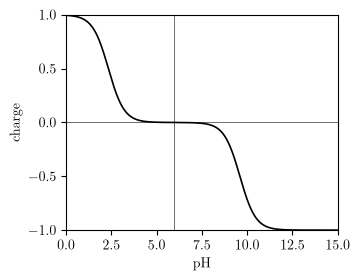

  pI = (pK1 + pK2)/2 = 5.9700      book: 5.97
  charge there       = -2.711e-20

  charge stays inside +/-0.01 over pH 4.34 to 7.60
  -- a flat region 3.26 pH units wide, which is why, as the
     illustration says, the isoelectric point cannot be read off Fig. 13.6-6
     by eye.  It is pK2 - pK1 - 2 log10(1/0.01) = 3.26 -- see Your turn, 5.


In [5]:
fig_6, ax = plt.subplots(figsize=(3.7, 2.9))
ax.plot(pH, glycine.charge(pH), "-", color="k", lw=1.2)
ax.axhline(0.0, color="k", lw=0.4, zorder=0)
ax.axvline(glycine.pI, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("charge")
ax.set_xlim(0, 15); ax.set_ylim(-1, 1); ax.set_yticks([-1, -0.5, 0, 0.5, 1])
fig_6.tight_layout(); plt.show()

print(f"  pI = (pK1 + pK2)/2 = {glycine.pI:.4f}      book: 5.97")
print(f"  charge there       = {float(glycine.charge(glycine.pI)):.3e}")
print(f"\n  charge stays inside +/-0.01 over pH "
      f"{pH[np.abs(glycine.charge(pH)) < 0.01][0]:.2f} to "
      f"{pH[np.abs(glycine.charge(pH)) < 0.01][-1]:.2f}")
w = pH[np.abs(glycine.charge(pH)) < 0.01]
print(f"  -- a flat region {w[-1] - w[0]:.2f} pH units wide, which is why, as the")
print("     illustration says, the isoelectric point cannot be read off Fig. 13.6-6")
print(f"     by eye.  It is pK2 - pK1 - 2 log10(1/0.01) = "
      f"{glycine.pK2 - glycine.pK1 - 4:.2f} -- see Your turn, 5.")


## Temperature: the ammonium group moves, the carboxyl does not

Ionization is a reaction, so its equilibrium constant obeys the van 't Hoff equation.
Section 13.6 writes it as

$$\mathrm{p}K(T_2)=\mathrm{p}K(T_1)+\frac{\Delta_{\rm rxn}H}{2.303R}
\left(\frac{1}{T_2}-\frac{1}{T_1}\right)$$

and gives the two heats of ionization for glycine: about $-44.77$ kJ/mol for the ammonium
group and **approximately zero** for the carboxyl.

That asymmetry decides everything below. A near-zero $\Delta H$ means p$K_1$ does not move;
$-44.77$ kJ/mol is strongly exothermic, so p$K_2$ **rises** with temperature. And since
$\mathrm{pI}=(\mathrm{p}K_1+\mathrm{p}K_2)/2$, the isoelectric point rises with
temperature too.


In [6]:
print(f"{'T (C)':>7} {'pK1':>7} {'pK2':>8} {'pI':>8}")
for T in (0.0, 25.0, 37.0):
    aa = glycine.at_temperature(T)
    print(f"{T:7.1f} {aa.pK1:7.2f} {aa.pK2:8.3f} {aa.pI:8.3f}")
print("\n  book prints pK2 = 8.88 at 0 C and 9.90 at 37 C  -- both correct")
print("  book prints pI  = 6.12 at 0 C and 5.61 at 37 C  -- EXCHANGED")


  T (C)     pK1      pK2       pI
    0.0    2.34    8.882    5.611
   25.0    2.34    9.600    5.970
   37.0    2.34    9.903    6.122

  book prints pK2 = 8.88 at 0 C and 9.90 at 37 C  -- both correct
  book prints pI  = 6.12 at 0 C and 5.61 at 37 C  -- EXCHANGED


## The printed isoelectric points at 0 °C and 37 °C are the wrong way round

Section 13.6's last paragraph: *"the isoelectric point shifts slightly from pH = 5.97 at
25 °C, to **5.61 at 37 °C and 6.12 at 0 °C**."*

Two sentences earlier the same paragraph gets the p$K$s right -- 9.90 at 37 °C, 8.88 at
0 °C. Adding the unchanged p$K_1=2.34$ and halving gives 6.12 at 37 °C and 5.61 at 0 °C.
The two values were transposed on their way into the sentence.

**Figure 13.6-11 has it right**, and the redrawn figure below shows why: the 0 °C curve
falls first, so it must cross zero first, so its pI is the lowest of the three.


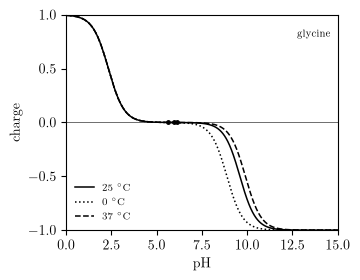

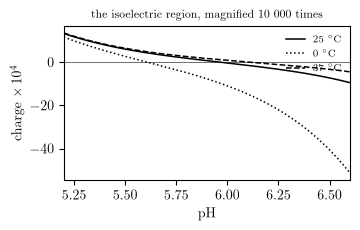

  the zero crossings, left to right:
      0.0 C   pI = 5.611
     25.0 C   pI = 5.970
     37.0 C   pI = 6.122


In [7]:
fig_11, ax = plt.subplots(figsize=(3.7, 2.9))
for T, ls, lab in [(25.0, "-", r"25 $^\circ$C"),
                   (0.0, ":", r"0 $^\circ$C"),
                   (37.0, "--", r"37 $^\circ$C")]:
    aa = glycine.at_temperature(T)
    ax.plot(pH, aa.charge(pH), ls, color="k", lw=1.1, label=lab)
    ax.plot([aa.pI], [0.0], "o", color="k", ms=2.5)
ax.axhline(0.0, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("charge")
ax.set_xlim(0, 15); ax.set_ylim(-1, 1); ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.legend(frameon=False, fontsize=7, loc="lower left")
# UPPER RIGHT, not upper left. At pH 0.5 the 25 C curve is on its way down from +1 and
# runs straight through the word; everything above charge 0 and right of pH 4 is empty.
ax.text(14.6, 0.82, "glycine", fontsize=7, ha="right", va="center")
fig_11.tight_layout(); plt.show()

# The same thing where it is actually visible. Exploration, not staged: the three curves
# of Fig. 13.6-11 are indistinguishable at print scale, which the printed figure
# cannot show and this panel can.
fig_zoom, ax = plt.subplots(figsize=(3.7, 2.4))
zoom = np.linspace(5.2, 6.6, 401)
for T, ls, lab in [(25.0, "-", r"25 $^\circ$C"), (0.0, ":", r"0 $^\circ$C"),
                   (37.0, "--", r"37 $^\circ$C")]:
    aa = glycine.at_temperature(T)
    ax.plot(zoom, aa.charge(zoom) * 1e4, ls, color="k", lw=1.1, label=lab)
ax.axhline(0.0, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel(r"charge $\times\,10^{4}$")
ax.set_xlim(5.2, 6.6)
ax.legend(frameon=False, fontsize=7, loc="upper right")
ax.set_title("the isoelectric region, magnified 10 000 times", fontsize=8)
fig_zoom.tight_layout(); plt.show()

print("  the zero crossings, left to right:")
for T in (0.0, 25.0, 37.0):
    print(f"    {T:5.1f} C   pI = {glycine.at_temperature(T).pI:.3f}")


## The deliverable art

`Figure_13.6-5.pdf`, `Figure_13.6-6.pdf` and `Figure_13.6-11.pdf`, written at the book's
figure size in Computer Modern, pure black ink. They are staged as `c13f018.pdf`,
`c13f019.pdf` and `c13f024.pdf`.

Fig. 13.6-11's line styles follow its printed caption -- 25 °C solid, 0 °C dotted, 37 °C
dashed -- and the p$K$, pI and zero guide lines are **black hairlines** rather than the
gray they were drafted in. The magnified panel above is exploration and is not staged: at
print scale the three curves of Fig. 13.6-11 lie on top of one another, which is exactly
why the printed figure cannot settle the transposed pI values and the numbers above can.


In [8]:
os.makedirs("pdf", exist_ok=True)
for figure, name in ((fig_5, "Figure_13.6-5"), (fig_6, "Figure_13.6-6"),
                     (fig_11, "Figure_13.6-11")):
    path = f"pdf/{name}.pdf"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")


  wrote pdf/Figure_13.6-5.pdf
  wrote pdf/Figure_13.6-6.pdf


  wrote pdf/Figure_13.6-11.pdf

  typography: LaTeX Computer Modern


## Your turn

1. Aspartic acid has three ionizable groups (p$K$ = 1.88, 3.65, 9.60) and lysine three as
   well (2.18, 8.95, 10.53). Compute each isoelectric point with `PolyproticAcid` and
   explain, from the *sign* of the middle group, why one is near 3 and the other near 10.
2. The section says $\Delta_{\rm ion}H$ for a carboxyl is "approximately 0". Look up a
   measured value for acetic acid's ionization and recompute the temperature shift of
   glycine's pI. Does it change the answer to the third digit?
3. A protein purification runs at 4 °C but the pI was measured at 25 °C. Using glycine's
   $-44.77$ kJ/mol as a stand-in for every ammonium group, estimate how far the pI of a
   protein with 19 basic and 13 acidic groups shifts on cooling.
4. Redo Fig. 13.6-6 with the ion activity coefficients included at $I = 0.15$ M. p$K_1$
   involves creating two charges and p$K_2$ involves moving one; predict which shifts more
   before you compute it.
5. Show that for a three-state amino acid the width of the pH interval over which
   $|{\rm charge}|<\epsilon$ is approximately
   $\mathrm{p}K_2-\mathrm{p}K_1-2\log_{10}(1/\epsilon)$, and check it against the number
   printed above for $\epsilon = 0.01$.
